In [1]:
# =============================================================
# CELL 1: Setup & Upload Data
# =============================================================
# Copy this into your first Colab cell and run it

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'figure.facecolor': 'white'})

from google.colab import files
uploaded = files.upload()  # Upload groundwater_urban_abstraction.csv here

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename, parse_dates=['Date'])
print(f'Loaded: {len(df):,} rows, {len(df.columns)} columns')
print(f'Period: {df["Date"].min().date()} to {df["Date"].max().date()}')

Saving groundwater_urban_abstraction (1).csv to groundwater_urban_abstraction (1).csv
Loaded: 7,300 rows, 17 columns
Period: 2005-01-01 to 2024-12-26


In [2]:
# =============================================================
# CELL 2: Data Inspection
# =============================================================

print(df.head(10).to_string())
print('\n')
df.info()
print('\n')
print(df.describe().round(2).to_string())
print('\nMissing values:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'None — dataset is complete.')

        Date  GWL_mbgl  Pumping_Rate_MLd  Rainfall_mm  Temperature_C  Effective_Recharge_mm  EC_uScm  Nitrate_mgL  Year  Month  DayOfYear  Weekday  Season  GWL_7d_avg  GWL_30d_avg  Pumping_7d_avg  Rain_30d_sum
0 2005-01-01      6.13              21.2          0.5            5.4                   0.09    486.0         19.2  2005      1          1        5  Winter        6.13         6.13            21.2           0.5
1 2005-01-02      6.25              32.7          0.3            3.0                   0.05    443.0         21.6  2005      1          2        6  Winter        6.19         6.19            27.0           0.8
2 2005-01-03      5.96              25.0          6.8            1.7                   1.22    474.0         18.2  2005      1          3        0  Winter        6.11         6.11            26.3           7.6
3 2005-01-04      6.11              25.0          7.1            0.1                   1.28    455.0         18.2  2005      1          4        1  Winter      

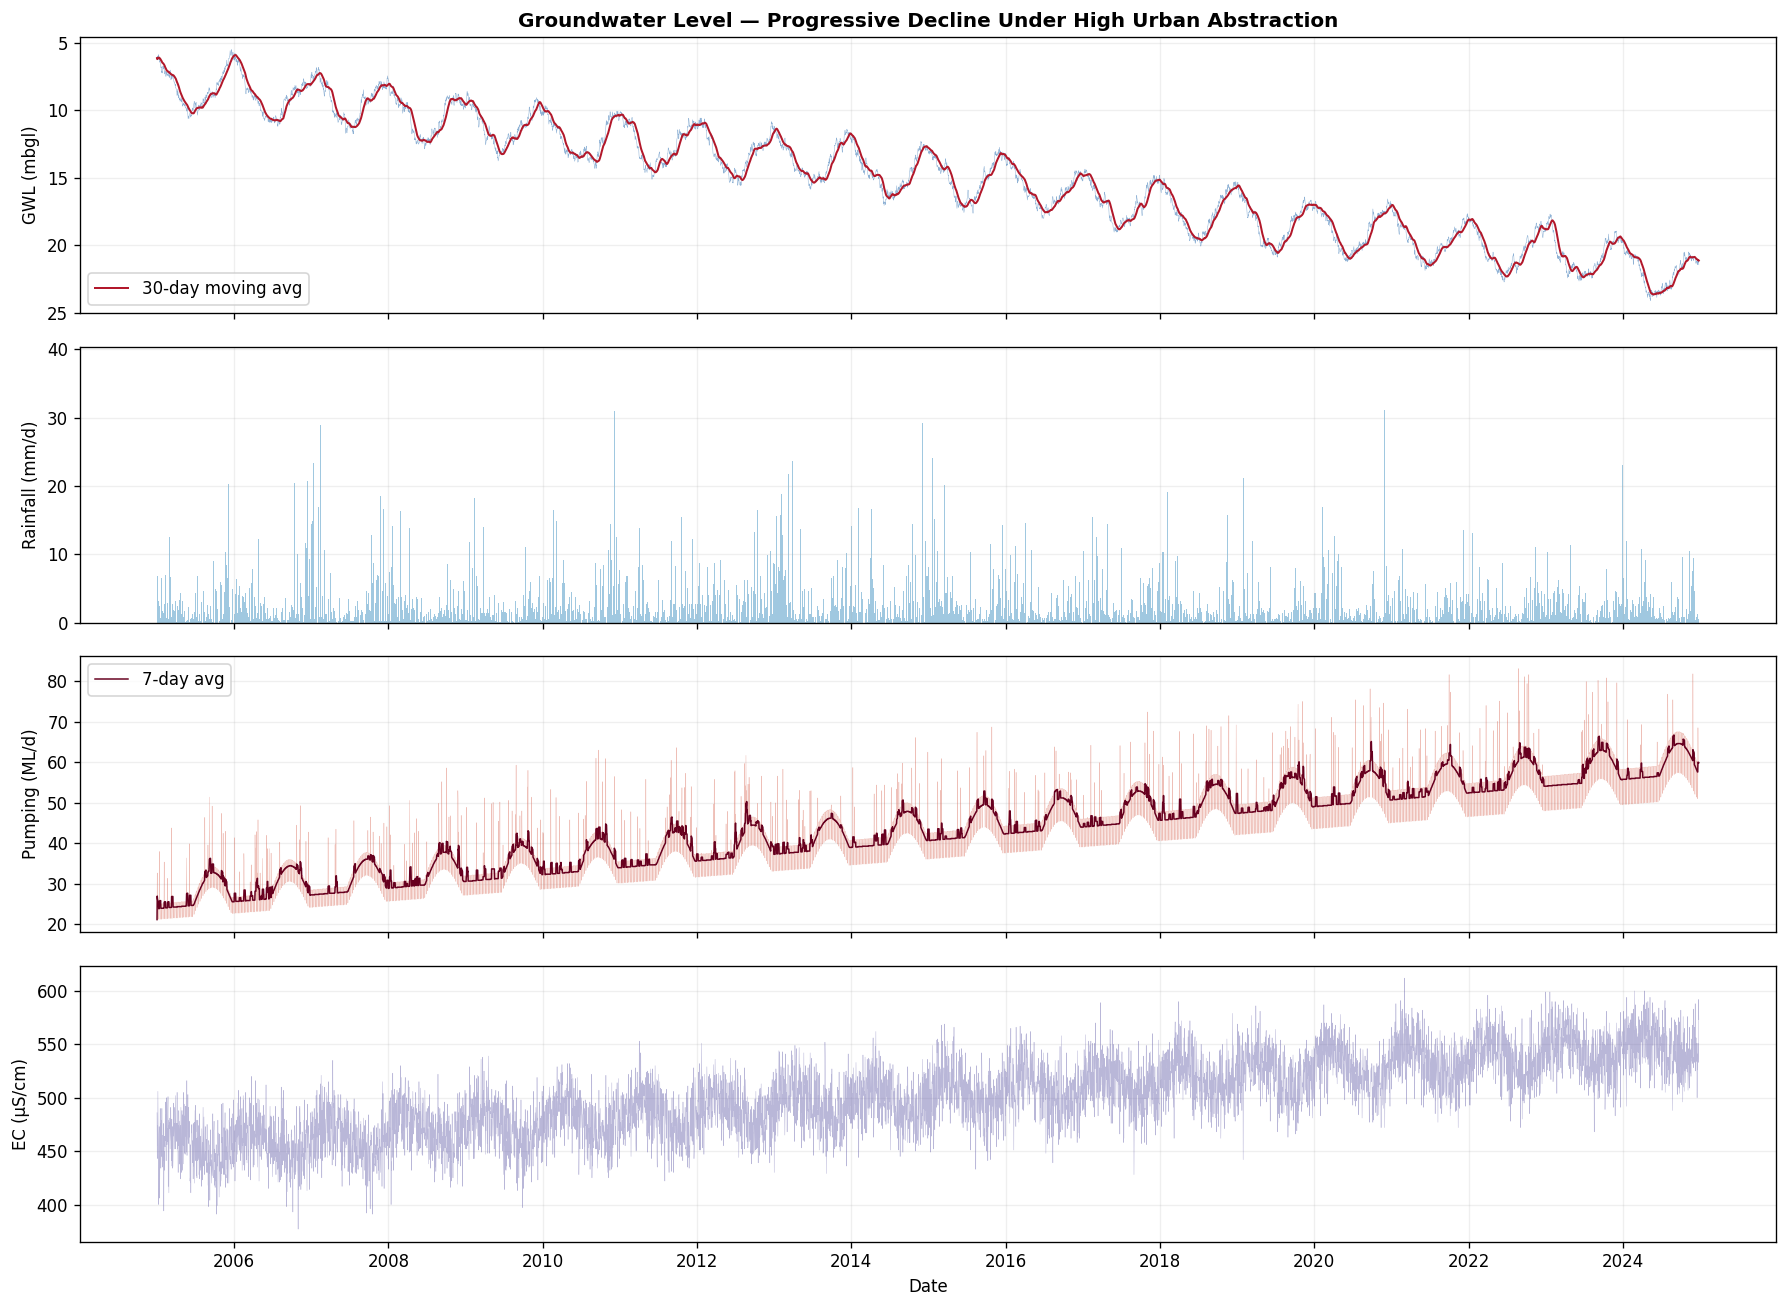

In [3]:
# =============================================================
# CELL 3: Time Series Overview Plot
# =============================================================

fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=True)

axes[0].plot(df['Date'], df['GWL_mbgl'], lw=0.3, color='#2166ac', alpha=0.5)
axes[0].plot(df['Date'], df['GWL_30d_avg'], lw=1.2, color='#b2182b', label='30-day moving avg')
axes[0].set_ylabel('GWL (mbgl)')
axes[0].set_title('Groundwater Level — Progressive Decline Under High Urban Abstraction',
                   fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].legend(loc='lower left')

axes[1].bar(df['Date'], df['Rainfall_mm'], width=1, color='#4393c3', alpha=0.5)
axes[1].set_ylabel('Rainfall (mm/d)')

axes[2].plot(df['Date'], df['Pumping_Rate_MLd'], lw=0.3, color='#d6604d', alpha=0.4)
axes[2].plot(df['Date'], df['Pumping_7d_avg'], lw=0.9, color='#67001f', label='7-day avg')
axes[2].set_ylabel('Pumping (ML/d)')
axes[2].legend(loc='upper left')

axes[3].plot(df['Date'], df['EC_uScm'], lw=0.3, color='#7570b3', alpha=0.5)
axes[3].set_ylabel('EC (µS/cm)')
axes[3].set_xlabel('Date')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

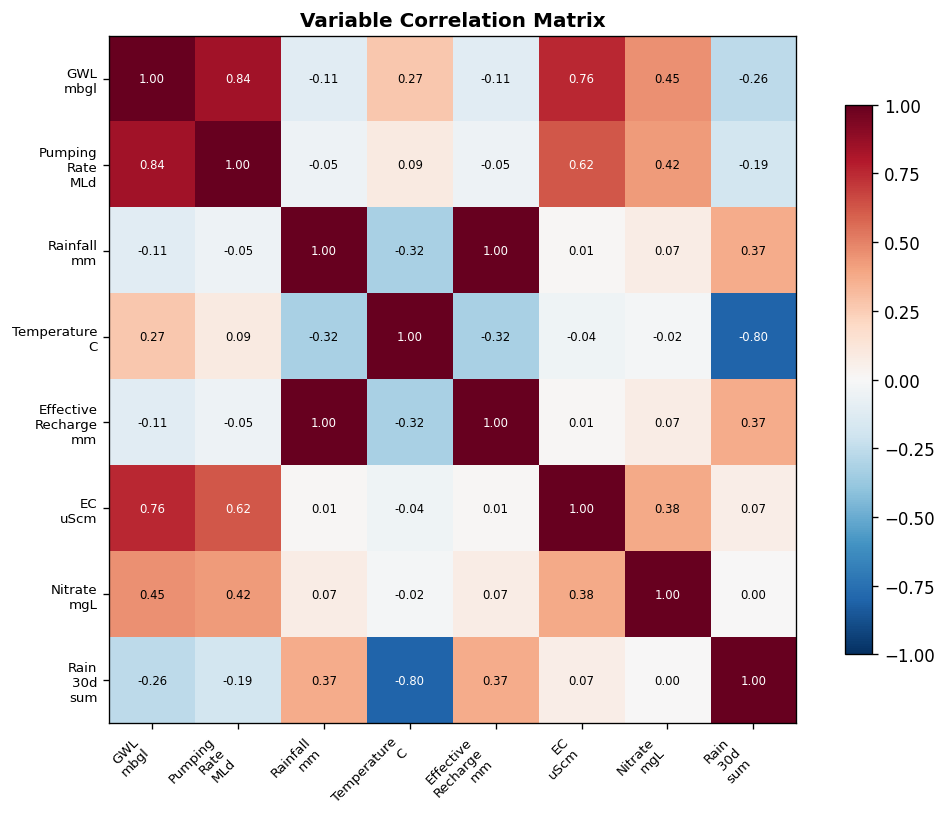


Correlations with GWL (sorted by strength):
  Pumping_Rate_MLd           r = +0.840
  EC_uScm                    r = +0.757
  Nitrate_mgL                r = +0.454
  Temperature_C              r = +0.272
  Rain_30d_sum               r = -0.264
  Rainfall_mm                r = -0.114
  Effective_Recharge_mm      r = -0.114


In [4]:
# =============================================================
# CELL 4: Correlation Matrix
# =============================================================

numeric_cols = ['GWL_mbgl','Pumping_Rate_MLd','Rainfall_mm','Temperature_C',
                'Effective_Recharge_mm','EC_uScm','Nitrate_mgL','Rain_30d_sum']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
labels = [c.replace('_', '\n') for c in numeric_cols]
ax.set_xticklabels(labels, fontsize=8, rotation=45, ha='right')
ax.set_yticklabels(labels, fontsize=8)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if abs(corr.values[i,j]) > 0.6 else 'black')

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Variable Correlation Matrix', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('\nCorrelations with GWL (sorted by strength):')
gwl_corr = corr['GWL_mbgl'].drop('GWL_mbgl').sort_values(key=abs, ascending=False)
for var, val in gwl_corr.items():
    print(f'  {var:25s}  r = {val:+.3f}')

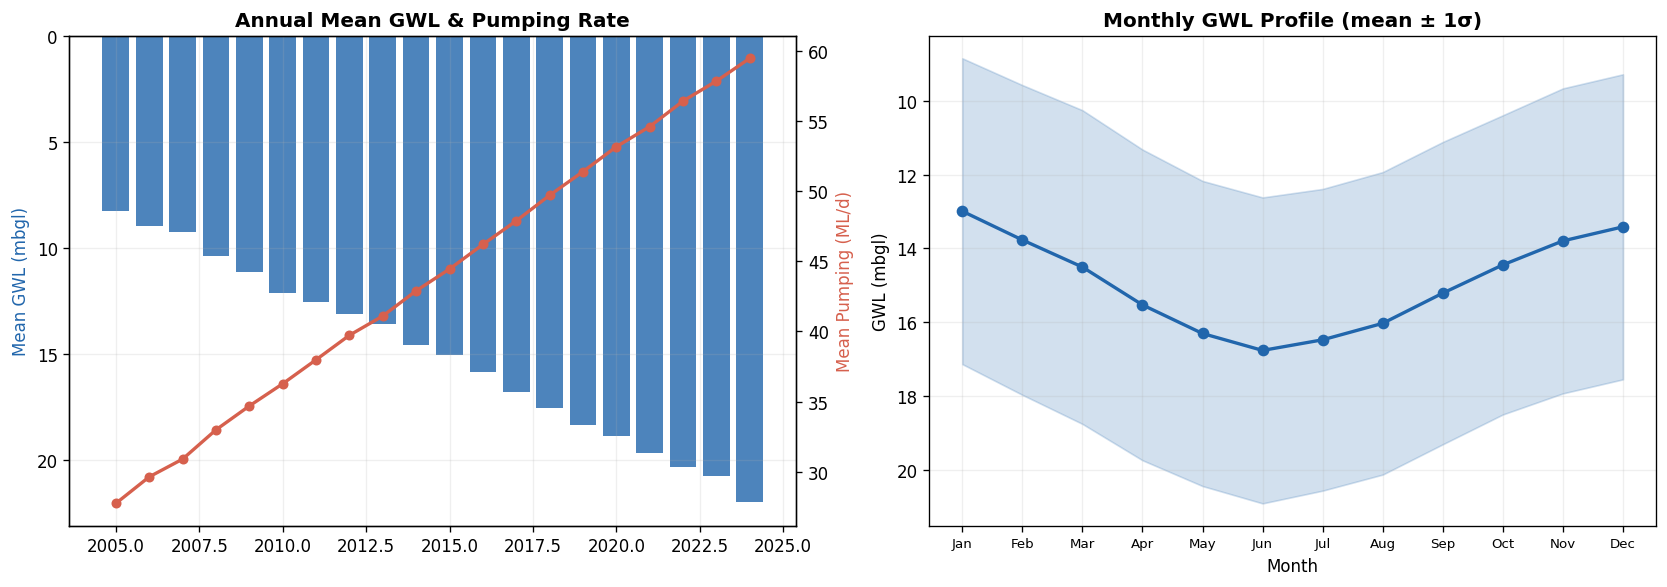

In [5]:
# =============================================================
# CELL 5: Seasonal & Annual Patterns
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

annual = df.groupby('Year').agg({'GWL_mbgl':'mean','Pumping_Rate_MLd':'mean'}).reset_index()
ax1 = axes[0]
ax1.bar(annual['Year'], annual['GWL_mbgl'], color='#2166ac', alpha=0.8)
ax1.set_ylabel('Mean GWL (mbgl)', color='#2166ac')
ax1.set_title('Annual Mean GWL & Pumping Rate', fontweight='bold')
ax1.invert_yaxis()
ax2 = ax1.twinx()
ax2.plot(annual['Year'], annual['Pumping_Rate_MLd'], 'o-', color='#d6604d', markersize=5, lw=2)
ax2.set_ylabel('Mean Pumping (ML/d)', color='#d6604d')

monthly = df.groupby('Month')['GWL_mbgl'].agg(['mean','std']).reset_index()
axes[1].fill_between(monthly['Month'], monthly['mean']-monthly['std'],
                      monthly['mean']+monthly['std'], alpha=0.2, color='#2166ac')
axes[1].plot(monthly['Month'], monthly['mean'], 'o-', color='#2166ac', markersize=6, lw=2)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('GWL (mbgl)')
axes[1].set_title('Monthly GWL Profile (mean ± 1σ)', fontweight='bold')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=8)
axes[1].invert_yaxis()

for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

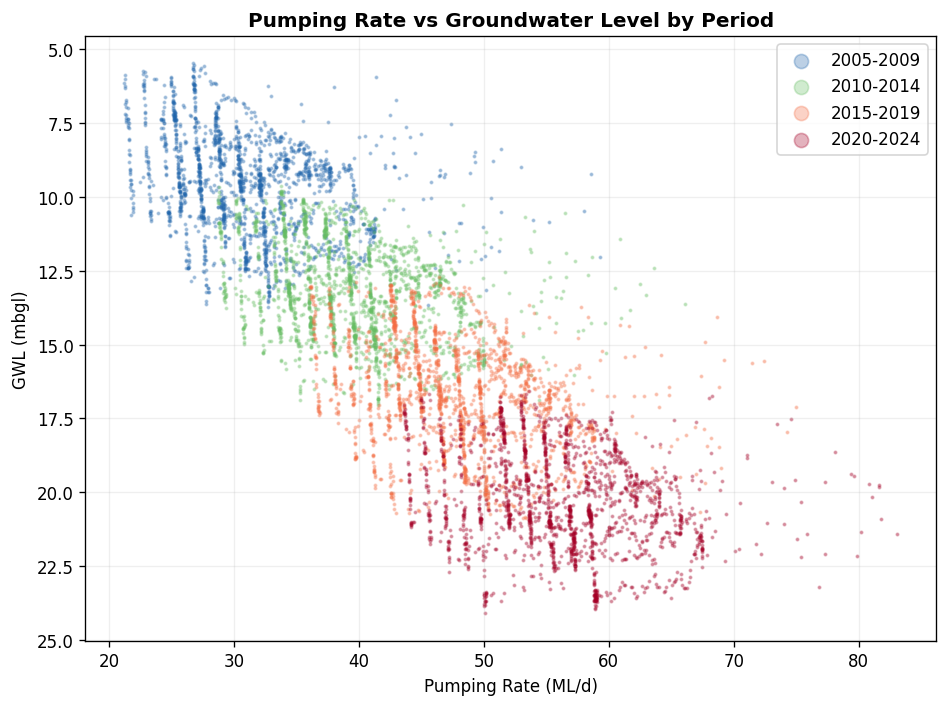

In [6]:
# =============================================================
# CELL 6: Pumping vs GWL Scatter by Period
# =============================================================

df['Decade'] = np.where(df['Year'] < 2010, '2005-2009',
               np.where(df['Year'] < 2015, '2010-2014',
               np.where(df['Year'] < 2020, '2015-2019', '2020-2024')))

fig, ax = plt.subplots(figsize=(8, 6))
colours = {'2005-2009': '#2166ac', '2010-2014': '#66bd63', '2015-2019': '#f46d43', '2020-2024': '#a50026'}
for period, colour in colours.items():
    mask = df['Decade'] == period
    ax.scatter(df.loc[mask, 'Pumping_Rate_MLd'], df.loc[mask, 'GWL_mbgl'],
               s=2, alpha=0.3, c=colour, label=period)
ax.set_xlabel('Pumping Rate (ML/d)')
ax.set_ylabel('GWL (mbgl)')
ax.set_title('Pumping Rate vs Groundwater Level by Period', fontweight='bold')
ax.invert_yaxis()
ax.legend(markerscale=6)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [7]:
# =============================================================
# CELL 7: Feature Engineering
# =============================================================

df['GWL_lag1'] = df['GWL_mbgl'].shift(1)
df['GWL_lag7'] = df['GWL_mbgl'].shift(7)
df['GWL_lag30'] = df['GWL_mbgl'].shift(30)
df['Pumping_lag1'] = df['Pumping_Rate_MLd'].shift(1)
df['Rain_lag7_sum'] = df['Rainfall_mm'].rolling(7, min_periods=1).sum()
df['GWL_diff_1d'] = df['GWL_mbgl'].diff(1)
df['GWL_diff_7d'] = df['GWL_mbgl'].diff(7)
df['Pumping_x_Temp'] = df['Pumping_Rate_MLd'] * df['Temperature_C']
df['Cum_Deficit'] = (df['Pumping_Rate_MLd'] * 0.01 - df['Effective_Recharge_mm']).cumsum()

df_ml = df.dropna().copy()
print(f'ML-ready rows: {len(df_ml):,} (dropped {len(df) - len(df_ml)} from lag creation)')
print(f'Total features available: {len(df_ml.columns)}')

ML-ready rows: 7,270 (dropped 30 from lag creation)
Total features available: 27


In [8]:
# =============================================================
# CELL 8: Train ML Models
# =============================================================

features = ['Pumping_Rate_MLd', 'Rainfall_mm', 'Temperature_C', 'Effective_Recharge_mm',
            'EC_uScm', 'Nitrate_mgL', 'Month', 'DayOfYear', 'Weekday',
            'Pumping_7d_avg', 'Rain_30d_sum', 'GWL_7d_avg', 'GWL_30d_avg',
            'GWL_lag1', 'GWL_lag7', 'GWL_lag30', 'Pumping_lag1',
            'Rain_lag7_sum', 'GWL_diff_1d', 'GWL_diff_7d',
            'Pumping_x_Temp', 'Cum_Deficit']

target = 'GWL_mbgl'

X = df_ml[features].values
y = df_ml[target].values

split_idx = int(len(df_ml) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_test = df_ml['Date'].values[split_idx:]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Training set: {len(X_train):,} samples')
print(f'Test set:     {len(X_test):,} samples')
print(f'Features:     {len(features)}')

models = {
    'Linear Regression': LinearRegression(),
    'Lasso (a=0.01)': Lasso(alpha=0.01, max_iter=5000),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=20, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, random_state=42),
}

results = {}
predictions = {}

print('\nModel Results:')
print('-' * 70)
for name, model in models.items():
    use_scaled = 'Linear' in name or 'Lasso' in name
    Xtr = X_train_s if use_scaled else X_train
    Xte = X_test_s if use_scaled else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    predictions[name] = y_pred

    print(f'{name:25s}  MAE={mae:.4f}m   RMSE={rmse:.4f}m   R2={r2:.5f}')

Training set: 5,816 samples
Test set:     1,454 samples
Features:     22

Model Results:
----------------------------------------------------------------------
Linear Regression          MAE=0.0000m   RMSE=0.0000m   R2=1.00000
Lasso (a=0.01)             MAE=0.0211m   RMSE=0.0243m   R2=0.99974
Random Forest              MAE=0.5037m   RMSE=0.8949m   R2=0.64378
Gradient Boosting          MAE=0.4349m   RMSE=0.8206m   R2=0.70046


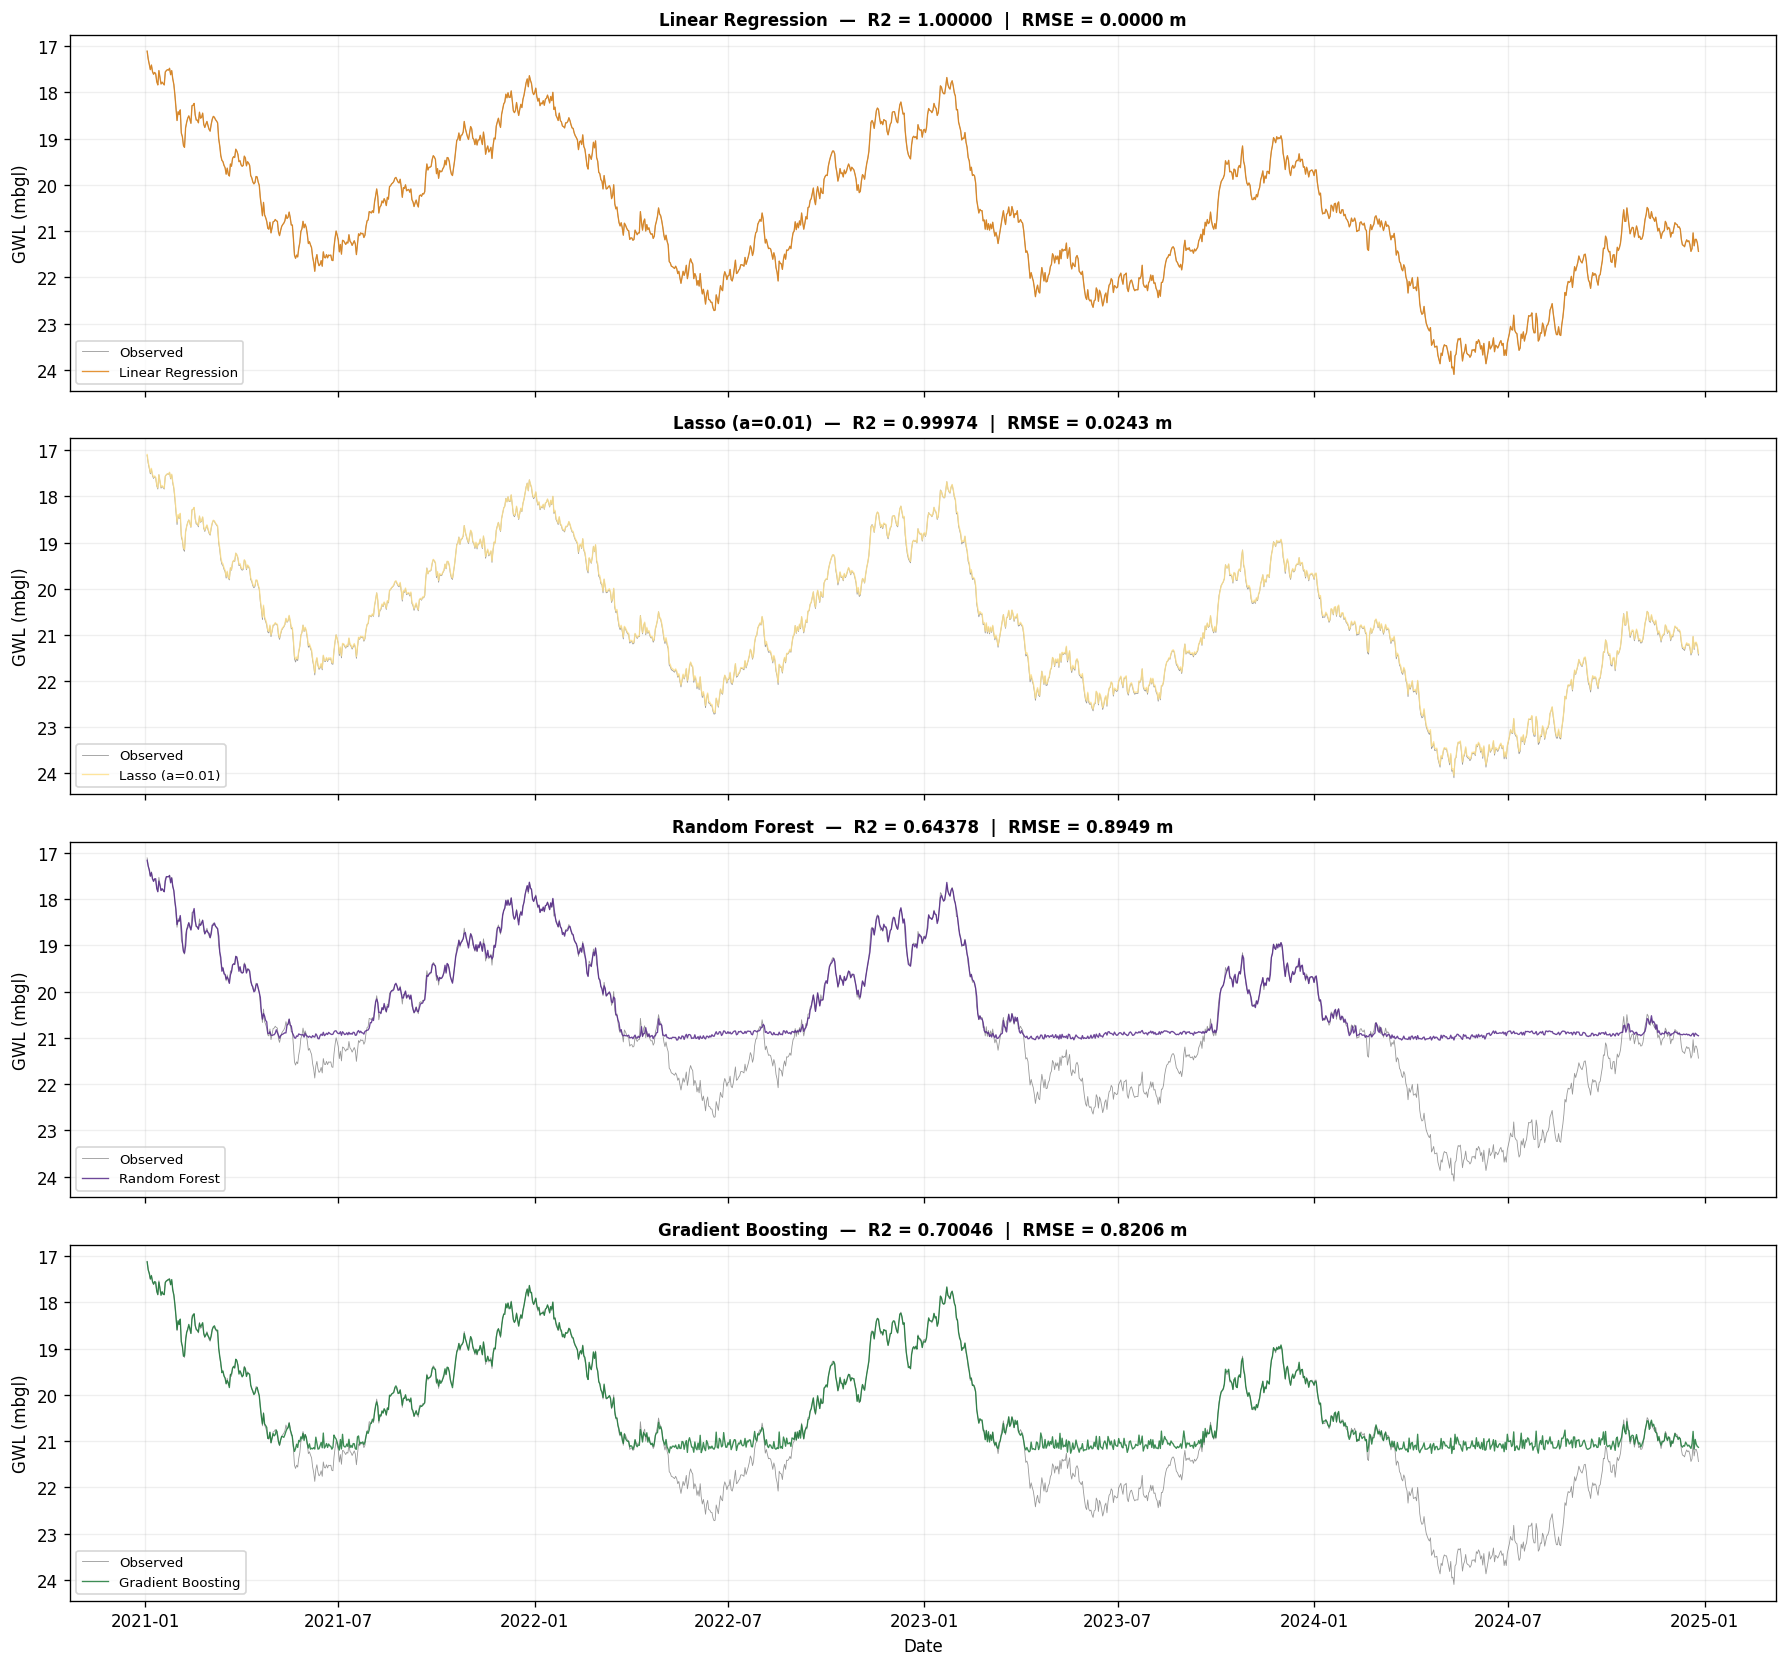

In [9]:
# =============================================================
# CELL 9: Model Predictions vs Observed
# =============================================================

model_colours = {'Linear Regression': '#e08214', 'Lasso (a=0.01)': '#fee08b',
                 'Random Forest': '#542788', 'Gradient Boosting': '#1b7837'}

fig, axes = plt.subplots(len(models), 1, figsize=(15, 3.5 * len(models)), sharex=True)

for idx, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx]
    ax.plot(dates_test, y_test, lw=0.5, color='#333', alpha=0.5, label='Observed')
    ax.plot(dates_test, y_pred, lw=0.8, color=model_colours[name], alpha=0.85, label=name)
    r2 = results[name]['R2']
    rmse = results[name]['RMSE']
    ax.set_ylabel('GWL (mbgl)')
    ax.set_title(f'{name}  —  R2 = {r2:.5f}  |  RMSE = {rmse:.4f} m',
                 fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

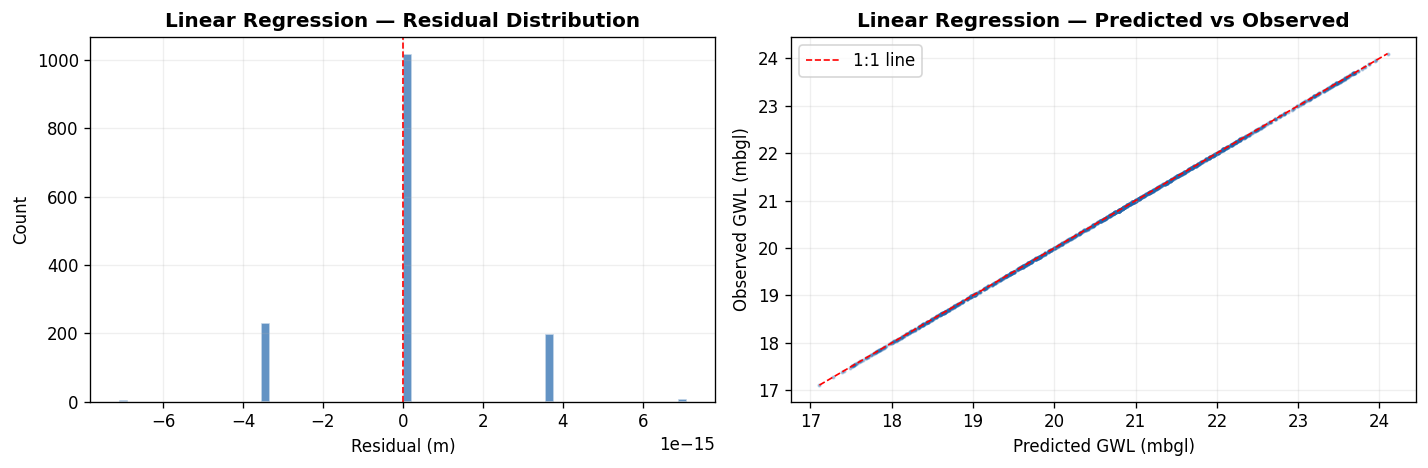

Residual mean: -0.0000 m
Residual std:  0.0000 m


In [10]:
# =============================================================
# CELL 10: Residual Analysis (Best Model)
# =============================================================

best_name = max(results, key=lambda k: results[k]['R2'])
residuals = y_test - predictions[best_name]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=60, color='#2166ac', alpha=0.7, edgecolor='white')
axes[0].axvline(0, color='red', ls='--', lw=1)
axes[0].set_xlabel('Residual (m)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'{best_name} — Residual Distribution', fontweight='bold')

axes[1].scatter(predictions[best_name], y_test, s=2, alpha=0.3, color='#2166ac')
lims = [min(y_test.min(), predictions[best_name].min()),
        max(y_test.max(), predictions[best_name].max())]
axes[1].plot(lims, lims, 'r--', lw=1, label='1:1 line')
axes[1].set_xlabel('Predicted GWL (mbgl)')
axes[1].set_ylabel('Observed GWL (mbgl)')
axes[1].set_title(f'{best_name} — Predicted vs Observed', fontweight='bold')
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f'Residual mean: {residuals.mean():.4f} m')
print(f'Residual std:  {residuals.std():.4f} m')

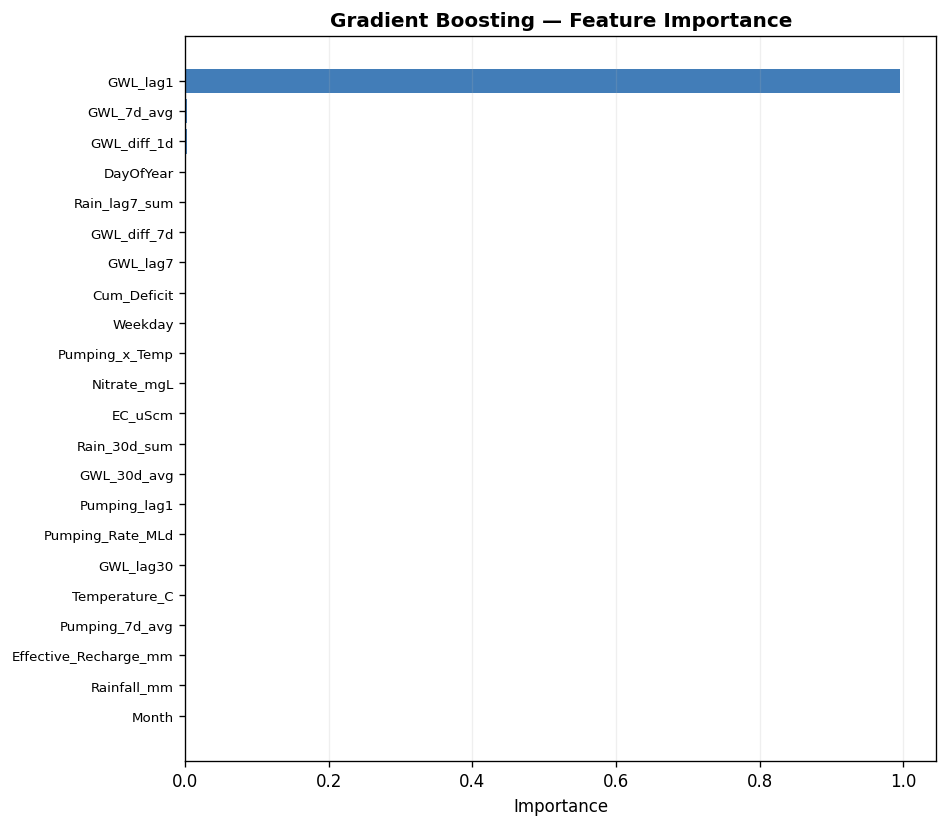

Top 10 features:
  GWL_lag1                   0.9960
  GWL_7d_avg                 0.0021
  GWL_diff_1d                0.0018
  DayOfYear                  0.0000
  Rain_lag7_sum              0.0000
  GWL_diff_7d                0.0000
  GWL_lag7                   0.0000
  Cum_Deficit                0.0000
  Weekday                    0.0000
  Pumping_x_Temp             0.0000


In [11]:
# =============================================================
# CELL 11: Feature Importance
# =============================================================

gb = models['Gradient Boosting']
importances = gb.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(range(len(features)), importances[sorted_idx], color='#2166ac', alpha=0.85)
ax.set_yticks(range(len(features)))
ax.set_yticklabels([features[i] for i in sorted_idx], fontsize=8)
ax.set_xlabel('Importance')
ax.set_title('Gradient Boosting — Feature Importance', fontweight='bold')
ax.grid(alpha=0.2, axis='x')
plt.tight_layout()
plt.show()

print('Top 10 features:')
for i in list(reversed(sorted_idx))[:10]:
    print(f'  {features[i]:25s}  {importances[i]:.4f}')

In [12]:
# =============================================================
# CELL 12: Time Series Cross-Validation
# =============================================================

tscv = TimeSeriesSplit(n_splits=5)

print('Time Series Cross-Validation (5-fold):')
print('-' * 55)
for name, model in models.items():
    use_scaled = 'Linear' in name or 'Lasso' in name
    data = X_train_s if use_scaled else X_train
    scores = cross_val_score(model, data, y_train, cv=tscv, scoring='r2')
    print(f'{name:25s}  R2 = {scores.mean():.4f} +/- {scores.std():.4f}')

Time Series Cross-Validation (5-fold):
-------------------------------------------------------
Linear Regression          R2 = 1.0000 +/- 0.0000
Lasso (a=0.01)             R2 = 0.9985 +/- 0.0019
Random Forest              R2 = 0.8235 +/- 0.0659
Gradient Boosting          R2 = 0.8381 +/- 0.0621


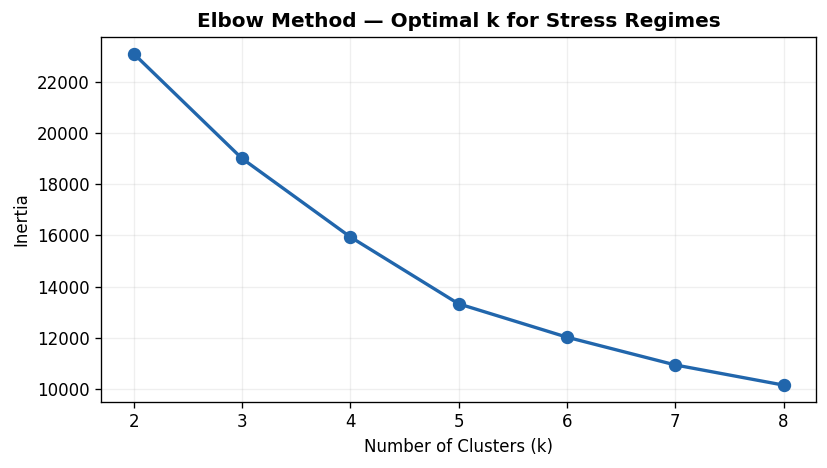

In [13]:
# =============================================================
# CELL 13: K-Means Clustering — Elbow Method
# =============================================================

cluster_features = ['GWL_mbgl', 'Pumping_Rate_MLd', 'Rainfall_mm', 'EC_uScm', 'Temperature_C']
X_clust = df[cluster_features].values
X_clust_s = StandardScaler().fit_transform(X_clust)

inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust_s)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, 'o-', color='#2166ac', lw=2, markersize=7)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — Optimal k for Stress Regimes', fontweight='bold')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


Cluster profiles (mean values):
                 GWL_mbgl  Pumping_Rate_MLd  Rainfall_mm  EC_uScm  Temperature_C
Stress_Regime                                                                   
Critical Stress     19.06             53.58         2.07   530.68          11.66
High Stress         13.45             41.18        12.54   499.52           6.14
Low Stress          10.81             35.40         2.65   479.29           6.03
Moderate Stress     12.98             37.24         1.52   474.65          16.06


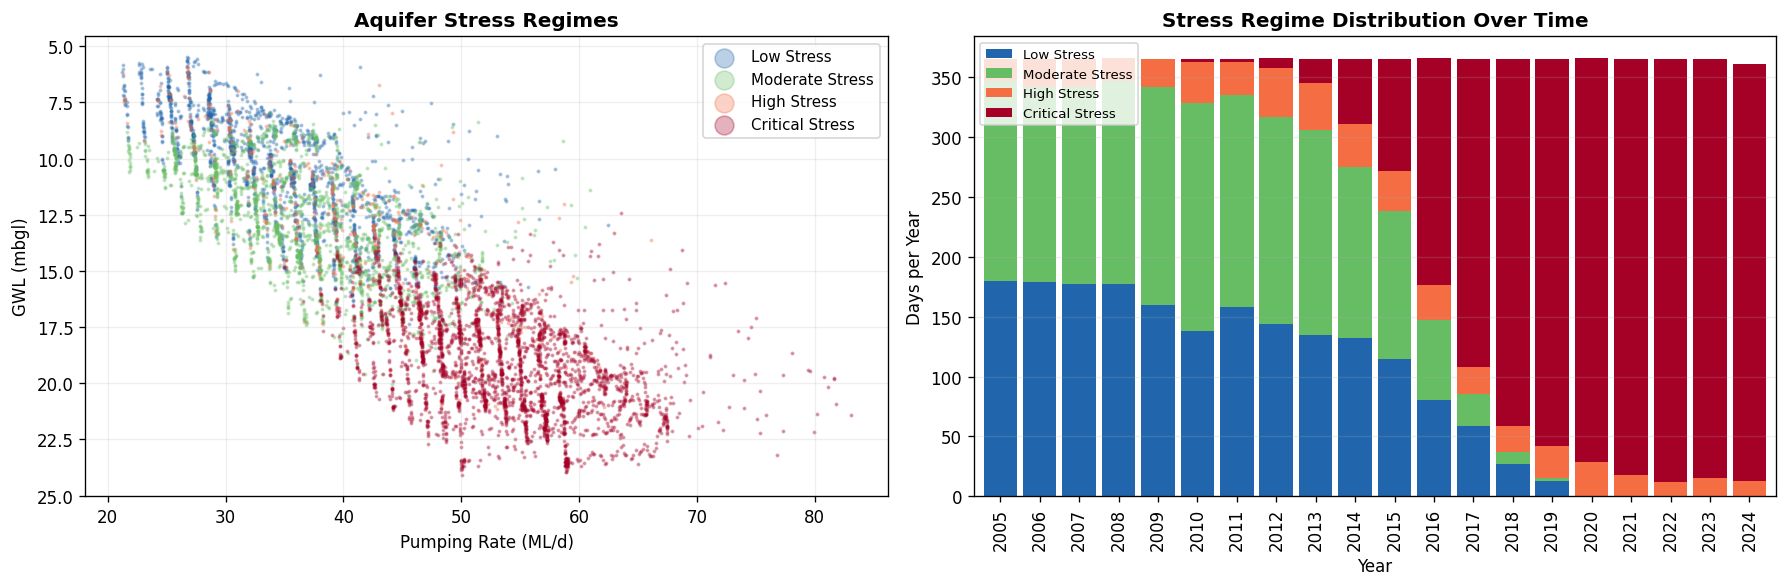

In [21]:
# =============================================================
# CELL 14: Fit Clusters & Visualise Stress Regimes
# =============================================================

km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(X_clust_s)

cluster_means = df.groupby('Cluster')['GWL_mbgl'].mean().sort_values()
stress_labels = ['Low Stress', 'Moderate Stress', 'High Stress', 'Critical Stress']
label_map = {clust: stress_labels[i] for i, clust in enumerate(cluster_means.index)}
df['Stress_Regime'] = df['Cluster'].map(label_map)

print('Cluster profiles (mean values):')
print(df.groupby('Stress_Regime')[cluster_features].mean().round(2).to_string())

cmap = {'Low Stress': '#2166ac', 'Moderate Stress': '#66bd63',
        'High Stress': '#f46d43', 'Critical Stress': '#a50026'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for regime, colour in cmap.items():
    mask = df['Stress_Regime'] == regime
    ax.scatter(df.loc[mask, 'Pumping_Rate_MLd'], df.loc[mask, 'GWL_mbgl'],
               s=2, alpha=0.3, c=colour, label=regime)
ax.set_xlabel('Pumping Rate (ML/d)')
ax.set_ylabel('GWL (mbgl)')
ax.set_title('Aquifer Stress Regimes', fontweight='bold')
ax.invert_yaxis()
ax.legend(markerscale=8, fontsize=9)
ax.grid(alpha=0.2)

ax = axes[1]
yearly_regime = df.groupby(['Year','Stress_Regime']).size().unstack(fill_value=0)
yearly_regime = yearly_regime[[c for c in stress_labels if c in yearly_regime.columns]]
yearly_regime.plot(kind='bar', stacked=True, ax=ax,
                   color=[cmap[c] for c in yearly_regime.columns], width=0.85)
ax.set_xlabel('Year')
ax.set_ylabel('Days per Year')
ax.set_title('Stress Regime Distribution Over Time', fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

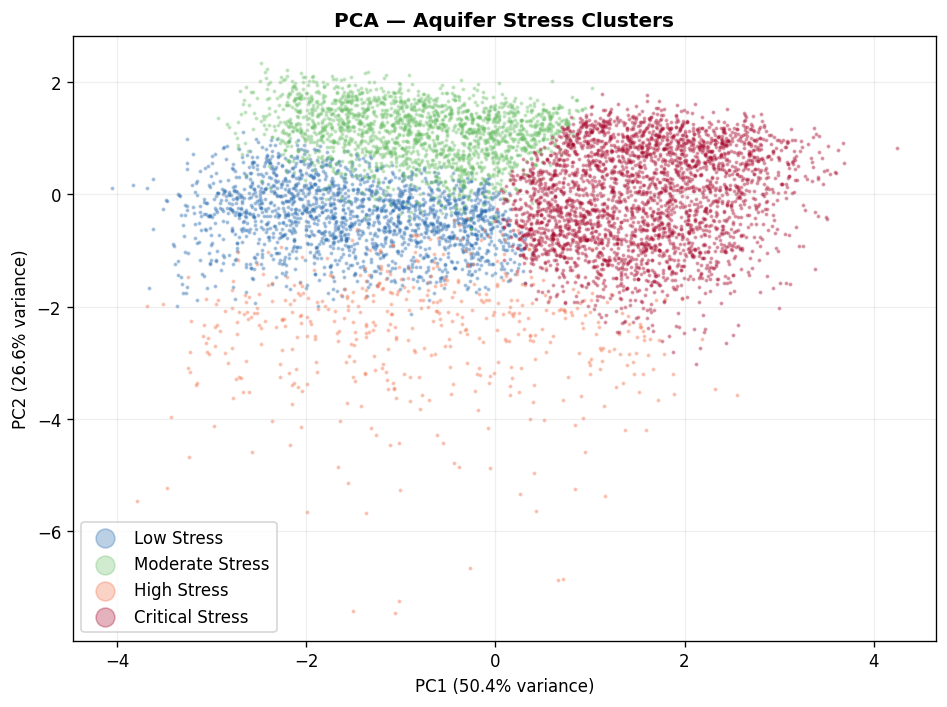

PCA loadings:
                    PC1    PC2
GWL_mbgl          0.609  0.021
Pumping_Rate_MLd  0.565 -0.093
Rainfall_mm      -0.094 -0.677
EC_uScm           0.529 -0.238
Temperature_C     0.148  0.690


In [22]:
# =============================================================
# CELL 15: PCA Visualisation of Clusters
# =============================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clust_s)

fig, ax = plt.subplots(figsize=(8, 6))
for regime, colour in cmap.items():
    mask = df['Stress_Regime'] == regime
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=2, alpha=0.3, c=colour, label=regime)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA — Aquifer Stress Clusters', fontweight='bold')
ax.legend(markerscale=8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print('PCA loadings:')
loadings = pd.DataFrame(pca.components_.T, index=cluster_features, columns=['PC1','PC2'])
print(loadings.round(3).to_string())

In [16]:
# =============================================================
# CELL 16: Summary of Key Findings
# =============================================================

first_5 = df[df['Year'] <= 2009]
last_5 = df[df['Year'] >= 2020]

print('=' * 65)
print('  SUMMARY: GROUNDWATER UNDER HIGH URBAN ABSTRACTION')
print('=' * 65)
print(f'''
  AQUIFER DECLINE
    Mean GWL 2005-2009:   {first_5["GWL_mbgl"].mean():.1f} mbgl
    Mean GWL 2020-2024:   {last_5["GWL_mbgl"].mean():.1f} mbgl
    Total deepening:      {last_5["GWL_mbgl"].mean() - first_5["GWL_mbgl"].mean():.1f} m

  PUMPING ESCALATION
    Mean pumping 2005-2009: {first_5["Pumping_Rate_MLd"].mean():.1f} ML/d
    Mean pumping 2020-2024: {last_5["Pumping_Rate_MLd"].mean():.1f} ML/d

  WATER QUALITY DETERIORATION
    Mean EC 2005-2009:     {first_5["EC_uScm"].mean():.0f} uS/cm
    Mean EC 2020-2024:     {last_5["EC_uScm"].mean():.0f} uS/cm

  ML PERFORMANCE (best model)''')
best = max(results, key=lambda k: results[k]['R2'])
print(f'    {best}: R2 = {results[best]["R2"]:.5f}, RMSE = {results[best]["RMSE"]:.4f} m')

crit_early = len(first_5[first_5.get('Stress_Regime', '') == 'Critical Stress']) if 'Stress_Regime' in first_5.columns else 0
crit_late = len(last_5[last_5.get('Stress_Regime', '') == 'Critical Stress']) if 'Stress_Regime' in last_5.columns else 0
print(f'''
  STRESS REGIME SHIFT
    Critical stress days 2005-2009: {crit_early}
    Critical stress days 2020-2024: {crit_late}
''')
print('=' * 65)

  SUMMARY: GROUNDWATER UNDER HIGH URBAN ABSTRACTION

  AQUIFER DECLINE
    Mean GWL 2005-2009:   9.6 mbgl
    Mean GWL 2020-2024:   20.3 mbgl
    Total deepening:      10.7 m

  PUMPING ESCALATION
    Mean pumping 2005-2009: 31.2 ML/d
    Mean pumping 2020-2024: 56.3 ML/d

  WATER QUALITY DETERIORATION
    Mean EC 2005-2009:     463 uS/cm
    Mean EC 2020-2024:     538 uS/cm

  ML PERFORMANCE (best model)
    Linear Regression: R2 = 1.00000, RMSE = 0.0000 m

  STRESS REGIME SHIFT
    Critical stress days 2005-2009: 0
    Critical stress days 2020-2024: 1735

